In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Load CSV files

rna = pd.read_csv(DATA_DIR / "rna_pam50.csv")
meth = pd.read_csv(DATA_DIR / "meth_pam50.csv")
clinical = pd.read_csv(DATA_DIR / "clinical_luminal_brca.csv")
labels = pd.read_csv(DATA_DIR / "labels_luminal_brca.csv")

In [ ]:
# check everything loaded correctly
print("RNA:", rna.shape)
print("Methylation:", meth.shape)
print("Clinical:", clinical.shape)
print("Labels:", labels.shape)

rna.head()

RNA: (563, 51)
Methylation: (563, 573)
Clinical: (563, 6)
Labels: (563, 2)


,patient,ANLN,FOXC1,CDH3,UBE2T,NDC80,PGR,BIRC5,ORC6,ESR1,...,BCL2,RRM2,GPR160,EXO1,UBE2C,TYMS,KRT5,KRT14,MAPT,MIA
0,TCGA-3C-AAAU,11.105826,5.775376,8.381510,9.812174,9.987982,12.562599,10.837751,9.170837,13.238924,...,12.731238,11.992955,11.903312,9.129882,10.683557,8.597176,2.672931,0.000000,14.408260,0.000000
1,TCGA-3C-AALJ,10.798701,8.822227,9.865672,11.047010,10.455039,10.397416,11.785657,10.106726,14.351766,...,12.895872,11.926050,10.570626,9.047426,11.816571,8.618023,4.147916,3.400342,13.026805,1.761133
2,TCGA-3C-AALK,10.823045,9.562867,11.422202,10.059636,9.025061,12.591963,11.625318,7.589228,12.770279,...,12.697965,11.333188,10.902748,8.492070,10.549321,8.500816,13.249594,13.595806,12.744965,2.098969
3,TCGA-4H-AAAK,10.028103,8.745877,10.680979,9.197335,9.013503,13.588389,10.488604,7.533092,13.957810,...,12.249068,10.113049,11.085132,8.097374,9.947966,8.582162,12.949840,12.940362,14.443390,0.000000
4,TCGA-5L-AAT0,8.363934,8.898627,10.963695,9.220853,8.026675,10.929867,9.263532,6.929919,14.101220,...,12.542410,9.744778,10.925444,7.468997,8.938684,7.419530,12.881304,12.866383,14.093355,2.453892


In [ ]:
# verify that the patient IDs are aligned across all files
assert rna["patient"].equals(meth["patient"])
assert rna["patient"].equals(labels["patient"])
assert rna["patient"].equals(clinical["patient"])

print("All files are aligned.")

All files are aligned.


In [ ]:
# check subtype counts
labels["subtype"].value_counts()

subtype
LumA    422
LumB    141
Name: count, dtype: int64

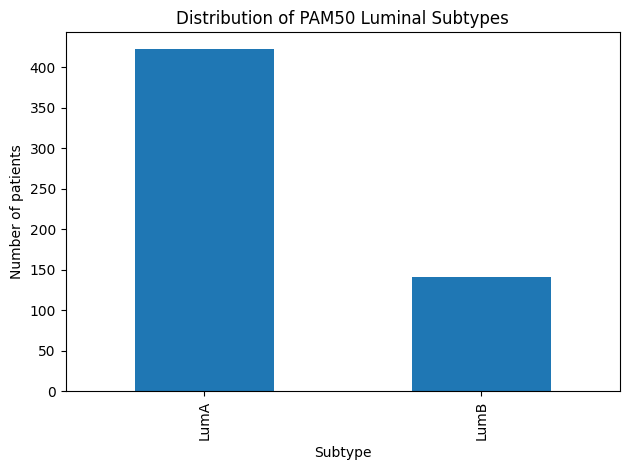

In [8]:
ax = labels["subtype"].value_counts().loc[["LumA", "LumB"]].plot(kind="bar")

ax.set_title("Distribution of PAM50 Luminal Subtypes")
ax.set_xlabel("Subtype")
ax.set_ylabel("Number of patients")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "subtype_distribution.png", dpi=300)
plt.show()

In [ ]:
# check rna and methylation feature counts
rna_features = [col for col in rna.columns if col != "patient"]
meth_features = [col for col in meth.columns if col != "patient"]

print("RNA features:", len(rna_features))
print("Methylation CpG features:", len(meth_features))

RNA features: 50
Methylation CpG features: 572


In [ ]:
# check missingness
print("RNA missing fraction:", rna[rna_features].isna().mean().mean())
print("Methylation missing fraction:", meth[meth_features].isna().mean().mean())

RNA missing fraction: 0.0
Methylation missing fraction: 0.09705747183544695


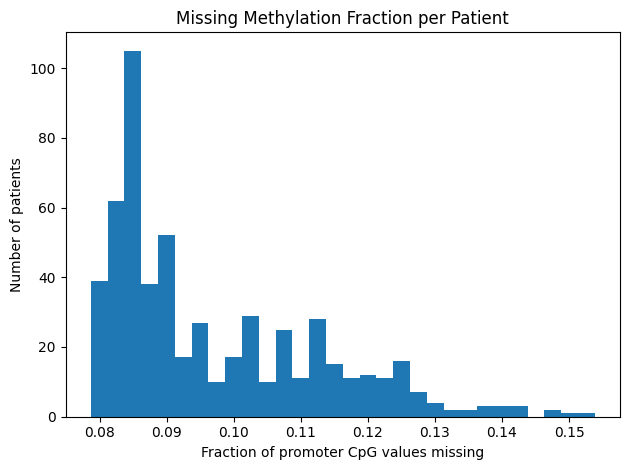

In [11]:
missing_per_patient = meth[meth_features].isna().mean(axis=1)

ax = missing_per_patient.plot(kind="hist", bins=30)

ax.set_title("Missing Methylation Fraction per Patient")
ax.set_xlabel("Fraction of promoter CpG values missing")
ax.set_ylabel("Number of patients")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "methylation_missingness_per_patient.png", dpi=300)
plt.show()

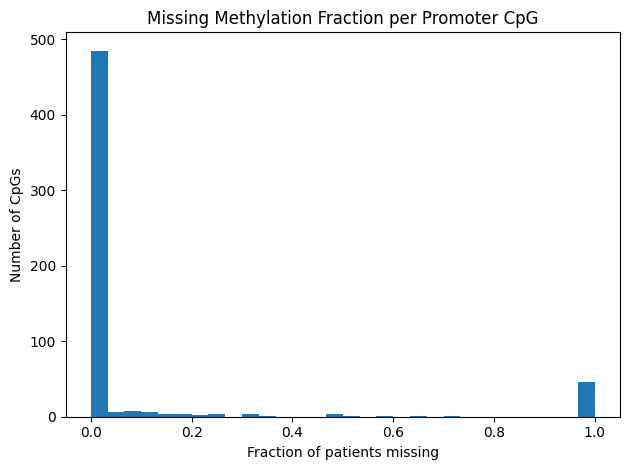

In [12]:
missing_per_cpg = meth[meth_features].isna().mean(axis=0)

ax = missing_per_cpg.plot(kind="hist", bins=30)

ax.set_title("Missing Methylation Fraction per Promoter CpG")
ax.set_xlabel("Fraction of patients missing")
ax.set_ylabel("Number of CpGs")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "methylation_missingness_per_cpg.png", dpi=300)
plt.show()

In [ ]:
# create survival status column
clinical.columns.tolist()

['patient',
 'BRCA_Subtype_PAM50',
 'vital_status',
 'year_of_death',
 'days_to_death',
 'days_to_last_follow_up']

In [14]:
[col for col in clinical.columns if any(
    word in col.lower()
    for word in ["survival", "vital", "death", "follow", "days"]
)]

['vital_status', 'year_of_death', 'days_to_death', 'days_to_last_follow_up']

In [15]:
clinical[[
    "patient",
    "BRCA_Subtype_PAM50",
    "vital_status",
    "days_to_death",
    "days_to_last_follow_up"
]].head()

,patient,BRCA_Subtype_PAM50,vital_status,days_to_death,days_to_last_follow_up
0,TCGA-3C-AAAU,LumA,Alive,NaN,4047.0
1,TCGA-3C-AALJ,LumB,Alive,NaN,1474.0
2,TCGA-3C-AALK,LumA,Alive,NaN,1448.0
3,TCGA-4H-AAAK,LumA,Alive,NaN,348.0
4,TCGA-5L-AAT0,LumA,Alive,NaN,1477.0


In [ ]:
# create a survival dataframe with patient ID, subtype, event status, and time
survival = clinical[[
    "patient",
    "BRCA_Subtype_PAM50",
    "vital_status",
    "days_to_death",
    "days_to_last_follow_up"
]].copy()

survival["event"] = np.where(survival["vital_status"] == "Dead", 1, 0)

survival["days_to_death"] = pd.to_numeric(
    survival["days_to_death"],
    errors="coerce"
)

survival["days_to_last_follow_up"] = pd.to_numeric(
    survival["days_to_last_follow_up"],
    errors="coerce"
)

survival["time"] = np.where(
    survival["event"] == 1,
    survival["days_to_death"],
    survival["days_to_last_follow_up"]
)

survival.head()

,patient,BRCA_Subtype_PAM50,vital_status,days_to_death,days_to_last_follow_up,event,time
0,TCGA-3C-AAAU,LumA,Alive,NaN,4047.0,0,4047.0
1,TCGA-3C-AALJ,LumB,Alive,NaN,1474.0,0,1474.0
2,TCGA-3C-AALK,LumA,Alive,NaN,1448.0,0,1448.0
3,TCGA-4H-AAAK,LumA,Alive,NaN,348.0,0,348.0
4,TCGA-5L-AAT0,LumA,Alive,NaN,1477.0,0,1477.0


In [ ]:
# clean survival data by dropping rows with missing or invalid time/event values
survival_clean = survival.dropna(subset=["time", "event"]).copy()
survival_clean = survival_clean[survival_clean["time"] > 0].copy()

print("Original patients:", len(survival))
print("Patients with valid survival data:", len(survival_clean))
print("Events:")
print(survival_clean["event"].value_counts())

Original patients: 563
Patients with valid survival data: 556
Events:
event
0    491
1     65
Name: count, dtype: int64


In [ ]:
# save cleaned survival data for future use
survival_clean.to_csv(
    DATA_DIR / "survival_luminal_clean.csv",
    index=False
)

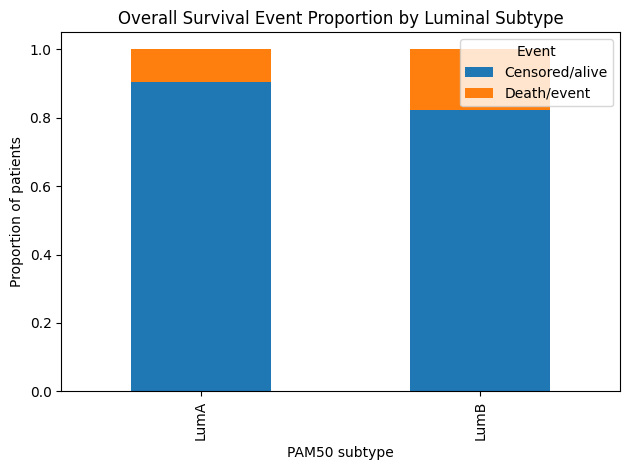

In [ ]:
event_table = pd.crosstab(
    survival_clean["BRCA_Subtype_PAM50"],
    survival_clean["event"],
    normalize="index"
)

ax = event_table.plot(kind="bar", stacked=True)

ax.set_title("Overall Survival Event Proportion by Luminal Subtype")
ax.set_xlabel("PAM50 subtype")
ax.set_ylabel("Proportion of patients")
ax.legend(title="Event", labels=["Censored/alive", "Death/event"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "survival_event_by_subtype.png", dpi=300)
plt.show()

In [ ]:
# create a summary table of key dataset characteristics
summary = pd.DataFrame({
    "metric": [
        "Patients with matched omics and clinical data",
        "Luminal A patients",
        "Luminal B patients",
        "PAM50 RNA features retained",
        "Promoter CpG methylation features retained",
        "Overall RNA missingness",
        "Overall methylation missingness",
        "Patients with valid survival outcome",
        "Deaths/events"
    ],
    "value": [
        len(labels),
        int((labels["subtype"] == "LumA").sum()),
        int((labels["subtype"] == "LumB").sum()),
        len(rna_features),
        len(meth_features),
        rna[rna_features].isna().mean().mean(),
        meth[meth_features].isna().mean().mean(),
        len(survival_clean),
        int(survival_clean["event"].sum())
    ]
})

summary 

,metric,value
0,Patients with matched omics and clinical data,563.000000
1,Luminal A patients,422.000000
2,Luminal B patients,141.000000
3,PAM50 RNA features retained,50.000000
4,Promoter CpG methylation features retained,572.000000
5,Overall RNA missingness,0.000000
6,Overall methylation missingness,0.097057
7,Patients with valid survival outcome,556.000000
8,Deaths/events,65.000000


In [ ]:
# save summary table
summary.to_csv(
    TABLES_DIR / "week1_data_summary.csv",
    index=False
)